# KQD Ising Chain — Size Extensivity (Exact Evolution, No Trotterization)

This notebook tests whether **Krylov Quantum Diagonalization (KQD)** is **size-extensive** for a
transverse-field Ising chain.

A method is size-extensive if the ground-state energy of a chain of $N$ spins scales **linearly**
with $N$:

$$E_0(N) \propto N$$

equivalently, $E_0(N)/N$ should be **independent of $N$** in the thermodynamic limit.

### What we do here (Steps 1–6)

| Step | Description |
|------|-------------|
| 1 | Build the transverse-field Ising Hamiltonian for a **6-spin ring** as a dense matrix |
| 2 | Choose the Néel state $|\uparrow\downarrow\uparrow\downarrow\uparrow\downarrow\rangle$ as the reference |
| 3 | Compute the optimal time-step $dt_{\text{opt}} = \pi / \|H\|_2$ |
| 4 | Build Krylov states exactly via `scipy.linalg.expm` (no Trotterization) |
| 5 | Assemble S and H̃ matrices; solve the regularised generalised eigenvalue problem |
| 6 | Plot KQD convergence as a function of Krylov dimension |

### Planned extensions (future cells)
- Sweep chain sizes $N = 2, 4, 6, 8, 10, 12$ (circular / periodic boundary conditions)
- Plot $E_0(N)/N$ vs $N$ — flat line = size-extensive
- Compare KQD vs exact diagonalisation for each $N$
- Optionally add Trotter-error analysis on top of the exact baseline


## Step 0 — Imports

In [9]:
import numpy as np
import scipy.linalg as la
import scipy as sp
import matplotlib
import matplotlib.pyplot as plt
import warnings
import os

os.makedirs("output", exist_ok=True)
warnings.filterwarnings("ignore")
print("Imports OK")


Imports OK


## Step 1 — Build the Transverse-Field Ising Hamiltonian

We consider the **1-D transverse-field Ising model** on a ring of $N$ spins with periodic
boundary conditions:

$$H = -J \sum_{\langle i,j \rangle} Z_i Z_j - h \sum_i X_i$$

where $J$ is the nearest-neighbour coupling and $h$ is the transverse field strength.  For
$J = h = 1$ the model is at the quantum critical point, giving maximal entanglement and a
non-trivial ground state — a good stress-test for KQD.

The Hamiltonian is built by hand as a $2^N \times 2^N$ dense NumPy matrix so that we can later
use `scipy.linalg.expm` for exact time evolution without any Trotter error.


In [10]:
# ── Pauli matrices ──────────────────────────────────────────────────────────
I2 = np.eye(2, dtype=complex)
X  = np.array([[0, 1],  [1, 0]],  dtype=complex)
Z  = np.array([[1, 0],  [0, -1]], dtype=complex)

def kron_op(op, site, n_spins):
    """Embed a single-site operator `op` at `site` in an n_spins tensor-product space."""
    ops = [I2] * n_spins
    ops[site] = op
    result = ops[0]
    for o in ops[1:]:
        result = np.kron(result, o)
    return result

def build_ising_hamiltonian(n_spins: int, J: float = 1.0, h: float = 1.0) -> np.ndarray:
    """
    Build the transverse-field Ising Hamiltonian on a periodic ring:

        H = -J * sum_{i} Z_i Z_{i+1}  -  h * sum_{i} X_i

    Parameters
    ----------
    n_spins : number of spins (qubits)
    J       : ZZ coupling strength  (default 1.0)
    h       : transverse-field (X) strength  (default 1.0)

    Returns
    -------
    H : (2**n_spins, 2**n_spins) complex Hermitian matrix
    """
    dim = 2 ** n_spins
    H = np.zeros((dim, dim), dtype=complex)

    # ZZ couplings — periodic boundary: site (n-1) couples to site 0
    for i in range(n_spins):
        j = (i + 1) % n_spins
        Zi = kron_op(Z, i, n_spins)
        Zj = kron_op(Z, j, n_spins)
        H -= J * (Zi @ Zj)

    # Transverse-field X terms
    for i in range(n_spins):
        H -= h * kron_op(X, i, n_spins)

    return H

# ── Build and inspect the 6-spin Hamiltonian ────────────────────────────────
N_SPINS = 6
J, h = 1.0, 1.0

H = build_ising_hamiltonian(N_SPINS, J=J, h=h)
dim = 2 ** N_SPINS

# Classical exact diagonalisation — ground truth
evals = np.linalg.eigvalsh(H)
E_exact = float(evals[0])

print(f"Ising chain  N={N_SPINS}  (J={J}, h={h}, PBC)")
print(f"Hilbert-space dimension : {dim}")
print(f"Exact ground-state energy : {E_exact:.10f}")
print(f"Energy per spin           : {E_exact / N_SPINS:.10f}")
print(f"Spectral norm ||H||_2     : {float(np.linalg.norm(H, ord=2)):.6f}")


Ising chain  N=6  (J=1.0, h=1.0, PBC)
Hilbert-space dimension : 64
Exact ground-state energy : -7.7274066103
Energy per spin           : -1.2879011017
Spectral norm ||H||_2     : 7.727407


## Step 2 — Reference State (Néel State)

We use the **Néel state** $|\uparrow\downarrow\uparrow\downarrow\uparrow\downarrow\rangle$
as the KQD reference.  In the computational basis this is the bitstring `|010101⟩` (spin-up = 0,
spin-down = 1 convention used by Qiskit), i.e. qubit 0 is up, qubit 1 is down, etc.

> **Why the Néel state?** It is a product state (trivially preparable on a quantum device), and it
> has a non-zero overlap with the antiferromagnetic ground state of the Ising model near the
> critical point.  The SKQD notebook uses the same reference for the XXZ chain.

The HF state used in the H₂ size-consistency notebook is the molecular analogue of this choice.


In [11]:
def neel_state(n_spins: int) -> np.ndarray:
    """
    Return the Néel state |↑↓↑↓...⟩ as a statevector.

    Convention: spin-up = |0⟩, spin-down = |1⟩.
    Bitstring for 6 spins: 010101 (binary) = 21 (decimal).
    """
    psi = np.zeros(2 ** n_spins, dtype=complex)
    # Build the bitstring: spin i is up (0) if i is even, down (1) if i is odd
    idx = sum(1 << (n_spins - 1 - i) for i in range(n_spins) if i % 2 == 1)
    psi[idx] = 1.0
    return psi

psi_ref = neel_state(N_SPINS)

# Sanity checks
assert abs(np.dot(psi_ref.conj(), psi_ref) - 1.0) < 1e-12, "Reference state not normalised"

ref_energy = float(np.real(psi_ref.conj() @ H @ psi_ref))
print(f"Reference (Néel) energy : {ref_energy:.10f}  (upper bound on E_exact)")
print(f"Exact GS energy         : {E_exact:.10f}")
print(f"Correlation energy      : {E_exact - ref_energy:.10f}  (should be negative)")

overlap_sq = abs(np.dot(psi_ref.conj(), np.linalg.eigh(H)[1][:, 0])) ** 2
print(f"|<ref|GS>|²             : {overlap_sq:.6f}  (should be > 0 for convergence)")


Reference (Néel) energy : 6.0000000000  (upper bound on E_exact)
Exact GS energy         : -7.7274066103
Correlation energy      : -13.7274066103  (should be negative)
|<ref|GS>|²             : 0.000462  (should be > 0 for convergence)


## Step 3 — Optimal Time-Step

Following Epperly, Lin & Nakatsukasa (2022), a provably sufficient choice for the KQD time-step
is:

$$dt_{\text{opt}} = \frac{\pi}{\|H\|_2}$$

where $\|H\|_2$ is the spectral norm (largest singular value).  This ensures the Krylov vectors
are spread far enough apart without wrapping around the spectrum.

We also define a sweep of scaled time-steps $\{0.3, 0.6, 1.0, 1.5\} \times dt_{\text{opt}}$
to visualise sensitivity — the same sweep used in the H₂ size-consistency notebook.


In [12]:
def compute_dt_opt(H_matrix: np.ndarray) -> float:
    """dt_opt = pi / ||H||_2  (spectral norm)."""
    return float(np.pi / np.linalg.norm(H_matrix, ord=2))

dt_opt = compute_dt_opt(H)
# DT_SCALES = [0.3, 0.6, 1.0, 1.5]
DT_SCALES = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

print(f"dt_opt = {dt_opt:.6f}")
for s in DT_SCALES:
    print(f"  dt_scale={s:.1f}  →  dt = {s*dt_opt:.6f}")


dt_opt = 0.406552
  dt_scale=0.1  →  dt = 0.040655
  dt_scale=0.2  →  dt = 0.081310
  dt_scale=0.3  →  dt = 0.121966
  dt_scale=0.4  →  dt = 0.162621
  dt_scale=0.5  →  dt = 0.203276
  dt_scale=0.6  →  dt = 0.243931
  dt_scale=0.7  →  dt = 0.284586
  dt_scale=0.8  →  dt = 0.325242
  dt_scale=0.9  →  dt = 0.365897
  dt_scale=1.0  →  dt = 0.406552


## Step 4 — Build Krylov States (Exact Matrix Exponentiation)

The Krylov basis is:

$$|k\rangle = e^{-iH \cdot k \cdot dt} |\text{ref}\rangle, \quad k = 0, 1, \ldots, d-1$$

**Key optimisation** (carried over from `krylov_h2_exact_sc.ipynb`): we compute the propagator
$U = e^{-iH \cdot dt}$ **once** via `scipy.linalg.expm`, then apply it iteratively:

$$|k\rangle = U |k-1\rangle$$

This replaces $O(d)$ expensive $O(N^3)$ matrix exponentials with **one** `expm` call plus $d-1$
cheap $O(N^2)$ matrix–vector products.


In [13]:
def build_krylov_states(H_matrix: np.ndarray, psi_ref: np.ndarray,
                         krylov_dim: int, dt: float) -> list:
    """
    Compute Krylov states |k> = exp(-iH k dt) |ref> for k = 0, ..., krylov_dim-1.

    Uses ONE expm call (U = expm(-iH dt)) then iterative mat-vec products.
    """
    U = la.expm(-1j * H_matrix * dt)          # single expensive O(N^3) call
    states = [psi_ref.copy().astype(complex)]  # k=0: reference state
    for _ in range(1, krylov_dim):
        states.append(U @ states[-1])          # k -> U|k-1>  (O(N^2))
    return states


def build_krylov_matrices(H_matrix: np.ndarray, states: list):
    """
    Build the full kd×kd overlap (S) and effective Hamiltonian (H̃) matrices.

    Called ONCE at max-dim; submatrices are extracted by slicing.
    Caches H|k> vectors to avoid recomputing H @ state for every (i,j) pair.
    """
    kd = len(states)
    S  = np.zeros((kd, kd), dtype=complex)
    Ht = np.zeros((kd, kd), dtype=complex)
    Hv = [H_matrix @ s for s in states]       # cache H|k>
    for i in range(kd):
        for j in range(kd):
            S[i, j]  = np.vdot(states[i], states[j])
            Ht[i, j] = np.vdot(states[i], Hv[j])
    return S, Ht


def solve_gen_eig(H_tilde: np.ndarray, S_tilde: np.ndarray,
                  threshold: float = 1e-10):
    """
    Solve the regularised generalised eigenvalue problem H̃ c = E S̃ c.

    Regularisation: project out eigenvectors of S with eigenvalue < threshold.
    Returns (ground_state_energy, effective_dimension).
    """
    svals, svecs = sp.linalg.eigh(S_tilde)
    svecs = svecs.T
    good  = np.array([v for val, v in zip(svals, svecs) if val >= threshold])
    if len(good) == 0:
        return np.nan, 0
    H_reg = good.conj() @ H_tilde @ good.T
    S_reg = good.conj() @ S_tilde @ good.T
    egs   = float(sp.linalg.eigh(H_reg, S_reg)[0][0].real)
    return egs, len(good)


def run_kqd_exact(H_matrix, psi_ref, krylov_dim, dt, threshold=1e-10,
                  states=None, S_full=None, H_full=None):
    """
    Run exact KQD for a given krylov_dim.

    Accepts precomputed states/matrices so that sweeping over krylov_dim
    inside a loop is O(1) extra expm calls (just slice the submatrix).
    """
    if states is None:
        states = build_krylov_states(H_matrix, psi_ref, krylov_dim, dt)
        S_full, H_full = build_krylov_matrices(H_matrix, states)

    S_tilde = S_full[:krylov_dim, :krylov_dim]
    H_tilde = H_full[:krylov_dim, :krylov_dim]
    egs, eff_dim = solve_gen_eig(H_tilde, S_tilde, threshold)
    s_evals = np.sort(np.linalg.eigvalsh(S_tilde).real)[::-1]

    return dict(
        gs_energy = egs,
        eff_dim   = eff_dim,
        S_tilde   = S_tilde,
        s_evals   = s_evals,
    )

print("KQD functions defined.")


KQD functions defined.


## Step 5 — Run KQD and Check Convergence

We sweep Krylov dimensions 1–10 for each of the four $dt$ scales.  For each $(dt, d_{\max})$
pair we:

1. Build all $d_{\max}$ Krylov states with **one** `expm` call.
2. Assemble the full $d_{\max} \times d_{\max}$ matrices **once**.
3. Extract sub-matrices $[0:d, 0:d]$ for each $d \in \{1,\ldots,d_{\max}\}$.


In [14]:
KRYLOV_DIMS = list(range(1, 15))   # sweep 1..15
MAX_DIM     = max(KRYLOV_DIMS)
THRESHOLD   = 1e-8                # S eigenvalue regularisation threshold

results = {}   # {dt_scale: [gs_energy_per_dim]}

for scale in DT_SCALES:
    dt_use = dt_opt * scale

    # Build all states and matrices ONCE at max dim
    states = build_krylov_states(H, psi_ref, MAX_DIM, dt_use)
    S_full, H_full = build_krylov_matrices(H, states)

    energies = []
    for dim in KRYLOV_DIMS:
        r = run_kqd_exact(H, psi_ref, dim, dt_use,
                          threshold=THRESHOLD,
                          states=states, S_full=S_full, H_full=H_full)
        energies.append(r["gs_energy"])

    results[scale] = energies

# Print summary at max Krylov dim for each dt scale
print(f"{'dt_scale':>10}  {'KQD E_GS':>16}  {'Exact E_GS':>16}  {'|Error| (Ha)':>14}")
print("-" * 62)
for scale in DT_SCALES:
    kqd_e = results[scale][-1]
    err   = abs(kqd_e - E_exact) if not np.isnan(kqd_e) else float("nan")
    print(f"{scale:>10.1f}  {kqd_e:>16.10f}  {E_exact:>16.10f}  {err:>14.4e}")


  dt_scale          KQD E_GS        Exact E_GS    |Error| (Ha)
--------------------------------------------------------------
       0.1     -7.4657730832     -7.7274066103      2.6163e-01
       0.2     -7.6752618331     -7.7274066103      5.2145e-02
       0.3     -7.7271822803     -7.7274066103      2.2433e-04
       0.4     -7.7274066103     -7.7274066103      1.4817e-11
       0.5     -7.7274066103     -7.7274066103      2.1290e-12
       0.6     -7.7274066103     -7.7274066103      6.2261e-13
       0.7     -7.7274066103     -7.7274066103      7.3630e-13
       0.8     -7.7274066103     -7.7274066103      1.4477e-13
       0.9     -7.7274066103     -7.7274066103      1.3767e-13
       1.0     -5.6568542495     -7.7274066103      2.0706e+00


## Step 6 — Convergence Plot

Plot $|E_{\text{KQD}} - E_{\text{exact}}|$ (log scale) vs Krylov dimension for each $dt$ scale.

Reference lines:
- **Chemical accuracy** 1.6 mHa ($1.6 \times 10^{-3}$ Ha) — standard threshold in quantum chemistry
- **Machine precision floor** $\approx 10^{-14}$ Ha


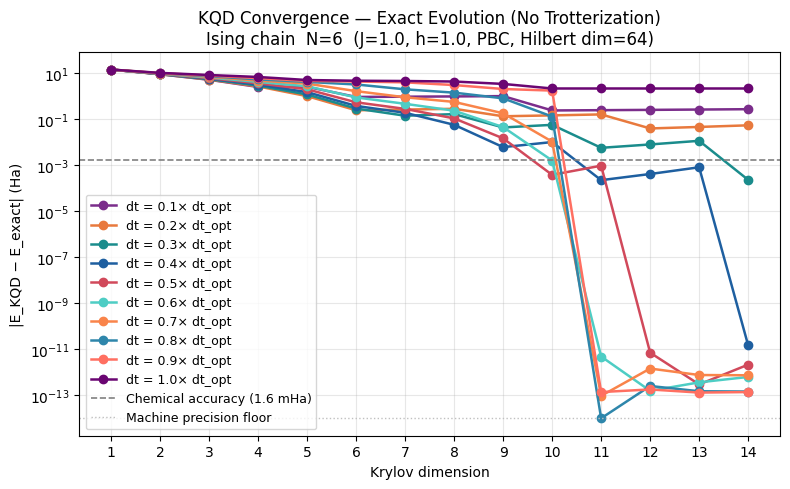

Plot saved → output/kqd_ising_convergence.png


In [15]:
CHEM_ACC  = 1.6e-3    # 1.6 mHa
MACH_PREC = 1e-14

colors = ["#7B2D8B", "#E8793D", "#1A8C8C", "#1E5FA0", "#D1495B", "#4ECDC4", "#F9844A", "#2E86AB", "#FF6F61", "#6A0572"]
labels = [f"dt = {s:.1f}× dt_opt" for s in DT_SCALES]

fig, ax = plt.subplots(figsize=(8, 5))

for scale, col, lbl in zip(DT_SCALES, colors, labels):
    errors = []
    for e in results[scale]:
        if np.isnan(e):
            errors.append(np.nan)
        else:
            err = abs(e - E_exact)
            errors.append(max(err, MACH_PREC))   # floor at machine precision
    ax.semilogy(KRYLOV_DIMS, errors, "o-", color=col, label=lbl, linewidth=1.8)

ax.axhline(CHEM_ACC,  color="gray",        linestyle="--", linewidth=1.2,
           label="Chemical accuracy (1.6 mHa)")
ax.axhline(MACH_PREC, color="silver",      linestyle=":",  linewidth=1.0,
           label="Machine precision floor")

ax.set_xlabel("Krylov dimension")
ax.set_ylabel("|E_KQD − E_exact| (Ha)")
ax.set_title(
    f"KQD Convergence — Exact Evolution (No Trotterization)\n"
    f"Ising chain  N={N_SPINS}  (J={J}, h={h}, PBC, Hilbert dim={2**N_SPINS})"
)
ax.set_xticks(KRYLOV_DIMS)
ax.legend(fontsize=9)
ax.grid(True, which="both", alpha=0.3)

plt.tight_layout()
fig.savefig("output/kqd_ising_convergence.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved → output/kqd_ising_convergence.png")


---
## Size-Extensivity Sweep

We now test whether KQD is **size-extensive** by sweeping chain sizes
$N \\in \\{2, 4, 6, 8, 10, 12\\}$ (even sizes preserve the Néel-state periodicity
and keep PBC well-defined).

A method is size-extensive if

$$\\frac{E_0(N)}{N} \\xrightarrow{N\\to\\infty} \\varepsilon_0 = \\text{const.}$$

We compare the **KQD estimate** with the **exact diagonalisation (ED)** value at each $N$
and inspect:

1. The energy-per-spin $E_0(N)/N$ for both KQD and ED.
2. The KQD error $|E_{\\text{KQD}}(N) - E_{\\text{ED}}(N)|$.
3. The fractional error $(E_{\\text{KQD}}(N) - E_{\\text{ED}}(N)) / |E_{\\text{ED}}(N)|$,
   which should remain **flat** in $N$ for a size-extensive method.

> **Memory note**: Dense matrix diagonalisation is feasible up to $N=14$
> ($2^{14}=16\\,384$). We cap at $N=12$ to keep runtimes short.


## Step 7 — Size Sweep: Run KQD & ED for N = 2, 4, …, 12

In [33]:
CHAIN_SIZES   = [2, 4, 6, 8, 10, 12]   # even sizes → valid Néel state
KRYLOV_DIM_EXT = 12   # fixed Krylov dim for the extensivity sweep
KRYLOV_DIM_LIST = [8, 10, 12, 14]
THRESHOLD_EXT  = 1e-10

sweep_results = {dim: [] for dim in KRYLOV_DIM_LIST}  # list of dicts, one per N
ed_results = []  # list of dicts, one per N

for N in CHAIN_SIZES:
    H_N     = build_ising_hamiltonian(N, J=J, h=h)
    psi_N   = neel_state(N)
    dt_N    = compute_dt_opt(H_N) * 0.2          # pi / ||H_N||_2

    # --- Exact diagonalisation ground truth ---
    E_ed = float(np.linalg.eigvalsh(H_N)[0])
    ed_results.append(dict(
        N = N,
        E_ed = E_ed,
        e_per_spin_ed = E_ed / N,
    ))

    for kd in KRYLOV_DIM_LIST:

    # --- KQD with fixed Krylov dimension (capped at Hilbert-space dim) ---
        kd_use  = min(kd, 2**N)   # can't exceed Hilbert-space size
        states_N   = build_krylov_states(H_N, psi_N, kd_use, dt_N)
        S_N, Ht_N  = build_krylov_matrices(H_N, states_N)
        res_N      = run_kqd_exact(H_N, psi_N, kd_use, dt_N,
                                threshold=THRESHOLD_EXT,
                                states=states_N, S_full=S_N, H_full=Ht_N)
        E_kqd = res_N['gs_energy']

        sweep_results[kd].append(dict(
            N          = N,
            kd_used    = kd_use,
            E_ed       = E_ed,
            E_kqd      = E_kqd,
            e_per_spin_ed  = E_ed  / N,
            e_per_spin_kqd = E_kqd / N if not np.isnan(E_kqd) else np.nan,
            abs_error  = abs(E_kqd - E_ed) if not np.isnan(E_kqd) else np.nan,
            frac_error = (E_kqd - E_ed) / abs(E_ed) if not np.isnan(E_kqd) else np.nan,
        ))

# Pretty-print table
print(f"{'N':>4} {'kd':>4} {'E_ED':>14} {'E_KQD':>14} "
      f"{'E/N (ED)':>12} {'E/N (KQD)':>12} {'|Error|':>12} {'Frac err':>12}")
print('-' * 90)
for r in sweep_results[8]:
    print(f"{r['N']:>4d} {r['kd_used']:>4d} "
          f"{r['E_ed']:>14.6f} {r['E_kqd']:>14.6f} "
          f"{r['e_per_spin_ed']:>12.6f} {r['e_per_spin_kqd']:>12.6f} "
          f"{r['abs_error']:>12.4e} {r['frac_error']:>12.4e}")


   N   kd           E_ED          E_KQD     E/N (ED)    E/N (KQD)      |Error|     Frac err
------------------------------------------------------------------------------------------
   2    4      -2.828427      -2.828427    -1.414214    -1.414214   4.4409e-16  -1.5701e-16
   4    8      -5.226252      -5.226252    -1.306563    -1.306563   8.3853e-12  -1.6045e-12
   6    8      -7.727407      -7.608235    -1.287901    -1.268039   1.1917e-01   1.5422e-02
   8    8     -10.251662      -9.666257    -1.281458    -1.208282   5.8540e-01   5.7103e-02
  10    8     -12.784906     -10.787276    -1.278491    -1.078728   1.9976e+00   1.5625e-01
  12    8     -15.322595     -11.182082    -1.276883    -0.931840   4.1405e+00   2.7022e-01


## Step 8 — Save Results to CSV

In [36]:
import csv, os

os.makedirs('output', exist_ok=True)
csv_path = 'output/kqd_ising_extensivity_kdim_sweep.csv'
fieldnames = ['N','kd_used','E_ed','E_kqd',
              'e_per_spin_ed','e_per_spin_kqd','abs_error','frac_error']

# with open(csv_path, 'w', newline='') as f:
#     writer = csv.DictWriter(f, fieldnames=fieldnames)
#     writer.writeheader()
#     writer.writerows(sweep_results)

# print(f'Saved → {csv_path}')

all_rows = [r for dims in KRYLOV_DIM_LIST for r in sweep_results[dim]]

with open(csv_path, 'w', newline='') as f:
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(all_rows)

print(f'Saved {len(all_rows)} rows → {csv_path}')


Saved 24 rows → output/kqd_ising_extensivity_kdim_sweep.csv


## Step 9 — Size-Extensivity Plots

Three sub-plots:

1. **Energy per spin** $E_0(N)/N$ vs $N$ for KQD and ED.
   A flat line as $N$ grows confirms extensivity.
2. **Absolute KQD error** $|E_{\\text{KQD}}(N) - E_{\\text{ED}}(N)|$ vs $N$
   (log scale). Should stay small and flat if KQD is well-calibrated.
3. **Fractional error** $(E_{\\text{KQD}} - E_{\\text{ED}}) / |E_{\\text{ED}}|$ vs $N$.
   Size extensivity is confirmed if this is roughly $N$-independent.


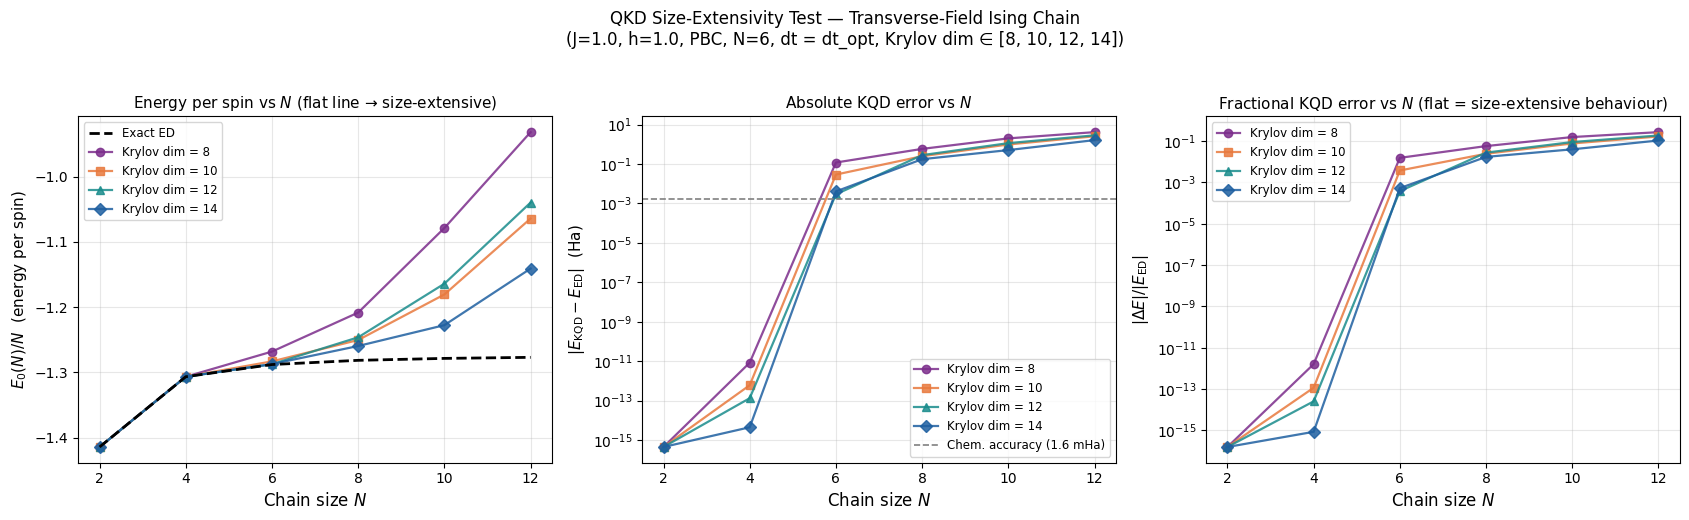

Plot saved → output/kqd_ising_kd_sweep_final.png


In [ ]:
CHEM_ACC  = 1.6e-3
MACH_PREC = 1e-14

colors  = ["#7B2D8B", "#E8793D", "#1A8C8C", "#1E5FA0"]
markers = ['o', 's', '^', 'D']

Ns     = CHAIN_SIZES
eps_ed = [r['e_per_spin_ed'] for r in ed_results]

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# ── Panel 1: E0(N)/N vs N ─────────────────────────────────────────────────────
ax = axes[0]
ax.plot(Ns, eps_ed, 'k--', linewidth=2, label='Exact ED', zorder=5)
for kd, col, mk in zip(KRYLOV_DIM_LIST, colors, markers):
    eps_kqd = [r['e_per_spin_kqd'] for r in sweep_results[kd]]
    ax.plot(Ns, eps_kqd, mk + '-', color=col, linewidth=1.6,
            markersize=6, label=f'Krylov dim = {kd}', alpha=0.85)
ax.set_xlabel('Chain size $N$', fontsize=12)
ax.set_ylabel('$E_0(N)/N$  (energy per spin)', fontsize=11)
ax.set_title('Energy per spin vs $N$ (flat line → size-extensive)', fontsize=11)
ax.set_xticks(Ns)
ax.legend(fontsize=8.5)
ax.grid(True, alpha=0.3)

# ── Panel 2: absolute error vs N ─────────────────────────────────────────────
ax = axes[1]
for kd, col, mk in zip(KRYLOV_DIM_LIST, colors, markers):
    abs_errs = [r['abs_error'] for r in sweep_results[kd]]
    ax.semilogy(Ns, abs_errs, mk + '-', color=col, linewidth=1.6,
                markersize=6, label=f'Krylov dim = {kd}', alpha=0.85)
ax.axhline(CHEM_ACC, color='gray', linestyle='--', linewidth=1.2,
           label='Chem. accuracy (1.6 mHa)')
ax.set_xlabel('Chain size $N$', fontsize=12)
ax.set_ylabel('$|E_\\mathrm{KQD} - E_\\mathrm{ED}|$  (Ha)', fontsize=11)
ax.set_title('Absolute KQD error vs $N$', fontsize=11)
ax.set_xticks(Ns)
ax.legend(fontsize=8.5)
ax.grid(True, which='both', alpha=0.3)

# ── Panel 3: fractional error vs N ───────────────────────────────────────────
ax = axes[2]
for kd, col, mk in zip(KRYLOV_DIM_LIST, colors, markers):
    frac_errs = [abs(r['frac_error']) for r in sweep_results[kd]]
    ax.semilogy(Ns, frac_errs, mk + '-', color=col, linewidth=1.6,
                markersize=6, label=f'Krylov dim = {kd}', alpha=0.85)
ax.set_xlabel('Chain size $N$', fontsize=12)
ax.set_ylabel('$|\\Delta E|/|E_\\mathrm{ED}|$', fontsize=11)
ax.set_title('Fractional KQD error vs $N$ (flat = size-extensive behaviour)', fontsize=11)
ax.set_xticks(Ns)
ax.legend(fontsize=8.5)
ax.grid(True, which='both', alpha=0.3)

plt.suptitle(
    f'QKD Size-Extensivity Test — Transverse-Field Ising Chain\n'
    f'(J={J}, h={h}, PBC, N={N_SPINS}, dt = dt_opt, '
    f'Krylov dim \u2208 {KRYLOV_DIM_LIST})',
    fontsize=12, y=1.03
)
plt.tight_layout()
fig.savefig('output/kqd_ising_kd_sweep_final.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved \u2192 output/kqd_ising_kd_sweep_final.png')
